This notebook reproduce Martin's (CND team) results on sonication vs line density

<>:89: SyntaxWarning: invalid escape sequence '\m'
<>:89: SyntaxWarning: invalid escape sequence '\m'
C:\Users\abd93000\AppData\Local\Temp\ipykernel_8756\119987851.py:89: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Mean Line Density (CNT/$\mu$m)")


Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


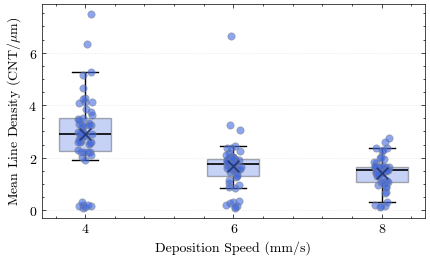

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
import scienceplots

plt.style.use(['science', 'no-latex'])

# ------------------------------
# Load Data
# ------------------------------
file_path = 'CNT_density_analysis_400-1837.xlsx'
df = pd.read_excel(file_path, header=0)

# Rows 9–69, Cols 2–4
line_density_rows = df.iloc[8:69, 1:4].apply(pd.to_numeric, errors='coerce')
line_density_rows.columns = [4, 6, 8]
means = line_density_rows.mean()

# ------------------------------
# Prepare plot
# ------------------------------
color_main = "#4169e1"     # Royal Blue
color_edge = "black"       # crisp outlines
scatter_edge = "gray"      # consistent with DICE figure

plt.figure(figsize=(4.5, 2.8))

print("Current font sizes:")
print(f"Font size: {plt.rcParams['font.size']}")
print(f"Axes labelsize: {plt.rcParams['axes.labelsize']}")
print(f"XTick labelsize: {plt.rcParams['xtick.labelsize']}")
print(f"YTick labelsize: {plt.rcParams['ytick.labelsize']}")

# ------------------------------
# BOXPLOT (blue transparent fill + black edges)
# ------------------------------
sns.boxplot(
    data=line_density_rows,
    width=0.35,
    linewidth=1.0,
    boxprops=dict(facecolor=color_main, alpha=0.3, edgecolor=color_edge),
    whiskerprops=dict(color=color_edge, linewidth=1.0),
    capprops=dict(color=color_edge, linewidth=1.0),
    medianprops=dict(color=color_edge, linewidth=1.2),
    fliersize=0,
)

# ------------------------------
# Scatter/jitter points (blue fill + gray edge)
# ------------------------------
for i, speed in enumerate(line_density_rows.columns):
    vals = line_density_rows[speed].dropna()
    jitter = 0.1 * (np.random.rand(len(vals)) - 0.5)
    # jitter = 0

    plt.scatter(
        np.full_like(vals, i) + jitter,
        vals,
        color=color_main,      # blue interior
        alpha=0.6,             # transparency (matched to looks)
        edgecolor=scatter_edge,
        linewidth=0.5,
        s=28,
        zorder=5,
    )

# ------------------------------
# Mean markers (darkened blue X)
# ------------------------------
dark = tuple(max(0, c * 0.55) for c in to_rgb(color_main))  # darker Royal Blue
for i, speed in enumerate(line_density_rows.columns):
    plt.scatter(
        i,
        means[speed],
        color=dark,
        marker="x",
        s=70,
        linewidth=1.3,
        zorder=10,
    )

# ------------------------------
# Labels / Formatting
# ------------------------------
plt.xlabel("Deposition Speed (mm/s)")
plt.ylabel("Mean Line Density (CNT/$\mu$m)")
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.xticks(ticks=range(len(means)), labels=means.index.astype(int))

plt.tight_layout()

# ------------------------------
# SAVE SVG
# ------------------------------
plt.savefig(
    r"C:\Users\abd93000\Downloads\downloads\paper figures\density_sonication_figure\density_sonication_blue_jitter.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# Monochrome version

<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
C:\Users\abd93000\AppData\Local\Temp\ipykernel_8756\130509959.py:86: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Mean Line Density (CNT/$\mu$m)")


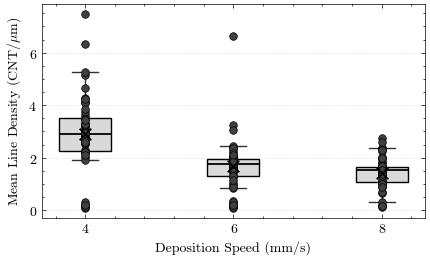

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
import scienceplots

plt.style.use(['science', 'no-latex'])

# ------------------------------
# Load Data
# ------------------------------
file_path = 'CNT_density_analysis_400-1837.xlsx'
df = pd.read_excel(file_path, header=0)

# Rows 9–69, Cols 2–4
line_density_rows = df.iloc[8:69, 1:4].apply(pd.to_numeric, errors='coerce')
line_density_rows.columns = [4, 6, 8]
means = line_density_rows.mean()

# ------------------------------
# Monochrome palette (ACS style)
# ------------------------------
box_face = "0.85"     # light gray fill
edge_col = "0.0"      # pure black edges
whisker_col = "0.2"   # dark gray whiskers
scatter_face = "0.25" # medium gray scatter points
scatter_edge = "0.0"  # black outlines
median_col = "0.0"    # black median
mean_col = "0.0"      # black X marker

plt.figure(figsize=(4.5, 2.8))

# ------------------------------
# Boxplot
# ------------------------------
sns.boxplot(
    data=line_density_rows,
    width=0.35,
    linewidth=1.0,
    boxprops=dict(facecolor=box_face, edgecolor=edge_col),
    whiskerprops=dict(color=whisker_col, linewidth=1.0),
    capprops=dict(color=whisker_col, linewidth=1.0),
    medianprops=dict(color=median_col, linewidth=1.3),
    fliersize=0,
    saturation=1
)

# ------------------------------
# Scatter (ACS monochrome spec)
# ------------------------------
for i, speed in enumerate(line_density_rows.columns):
    vals = line_density_rows[speed].dropna()
    # jitter = 0.1 * (np.random.rand(len(vals)) - 0.5)
    jitter = 0

    plt.scatter(
        np.full_like(vals, i) + jitter,
        vals,
        color=scatter_face,
        edgecolor=scatter_edge,
        linewidth=0.5,
        s=30,
        zorder=5
    )

# ------------------------------
# Means (bold black "×")
# ------------------------------
for i, speed in enumerate(line_density_rows.columns):
    plt.scatter(
        i,
        means[speed],
        color=mean_col,
        marker="x",
        s=70,
        linewidths=1.3,
        zorder=10
    )

# ------------------------------
# Axes & formatting (ACS compliant)
# ------------------------------
plt.xlabel("Deposition Speed (mm/s)")
plt.ylabel("Mean Line Density (CNT/$\mu$m)")

plt.grid(axis='y', linestyle='--', alpha=0.25, linewidth=0.6)
plt.xticks(ticks=range(len(means)), labels=means.index.astype(int))

plt.tight_layout()

# ------------------------------
# SAVE SVG (ACS vector format)
# ------------------------------
plt.savefig(
    r"C:\Users\abd93000\Downloads\downloads\paper figures\density_sonication_figure\density_sonication_mono_no_jitter.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
